DP columns: Index(['time', 'iInfeed.im', 'iInfeed.re', 'iLine1.im', 'iLine1.re',
       'iLine2.im', 'iLine2.re', 'iLoad1.im', 'iLoad1.re', 'iLoad2.im',
       'iLoad2.re', 'idConverter1', 'idConverter2', 'iqConverter1',
       'iqConverter2', 'vConverter1.im', 'vConverter1.re', 'vConverter2.im',
       'vConverter2.re', 'vInfeed.im', 'vInfeed.re', 'vLoad.im', 'vLoad.re',
       'vdConverter1', 'vdConverter2', 'vqConverter1', 'vqConverter2'],
      dtype='object')


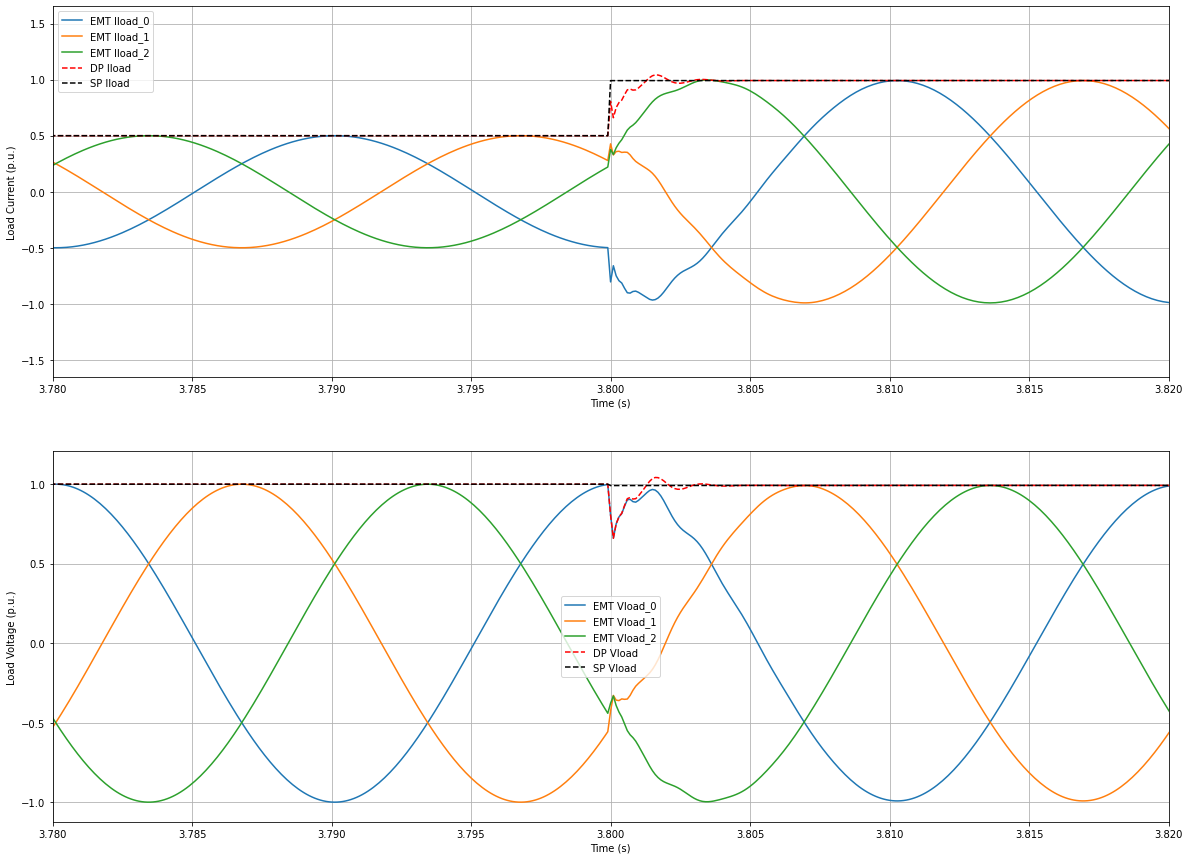

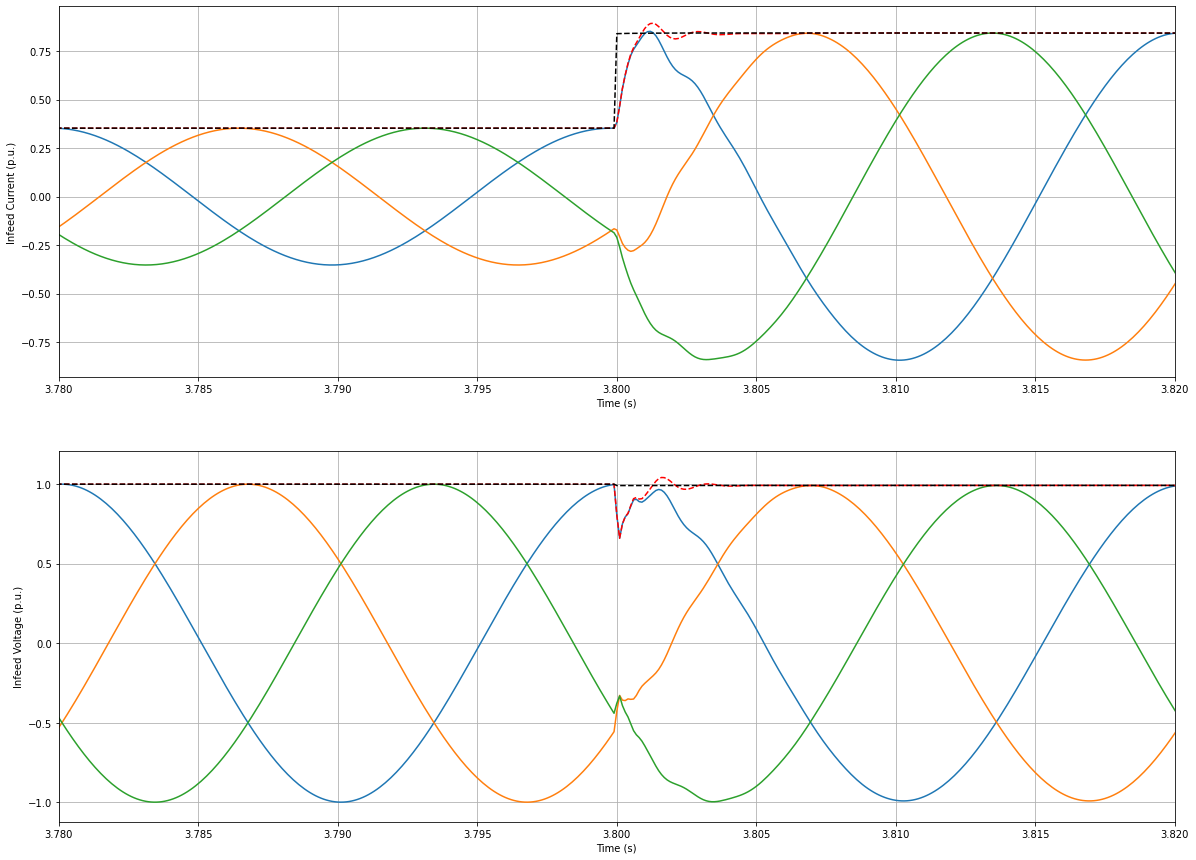

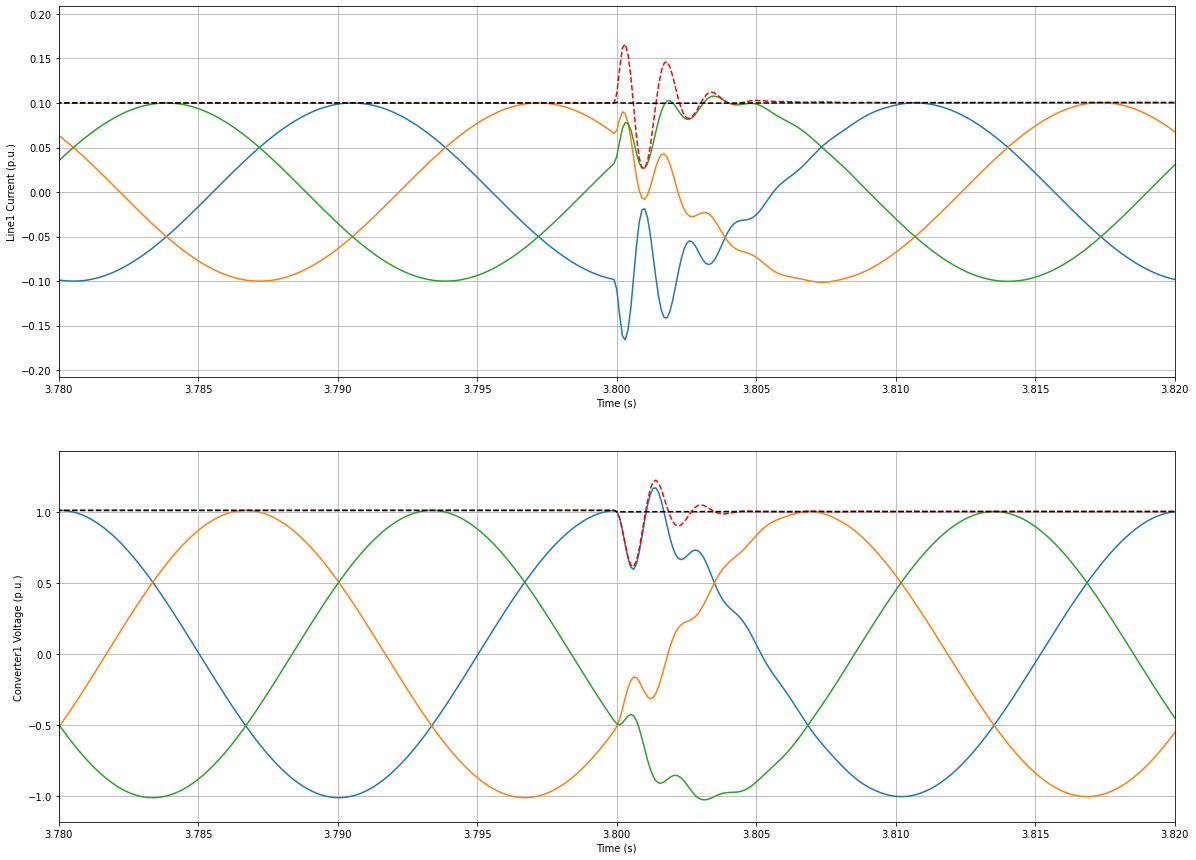

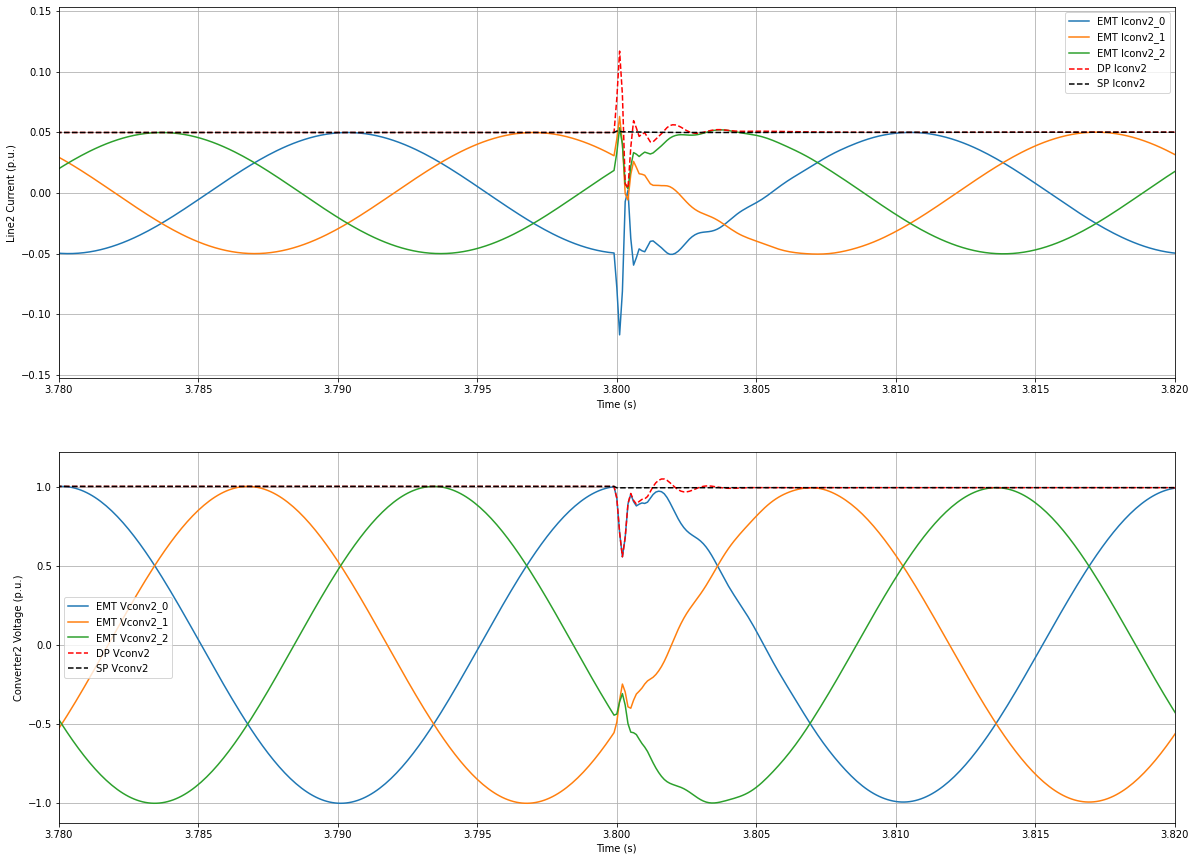

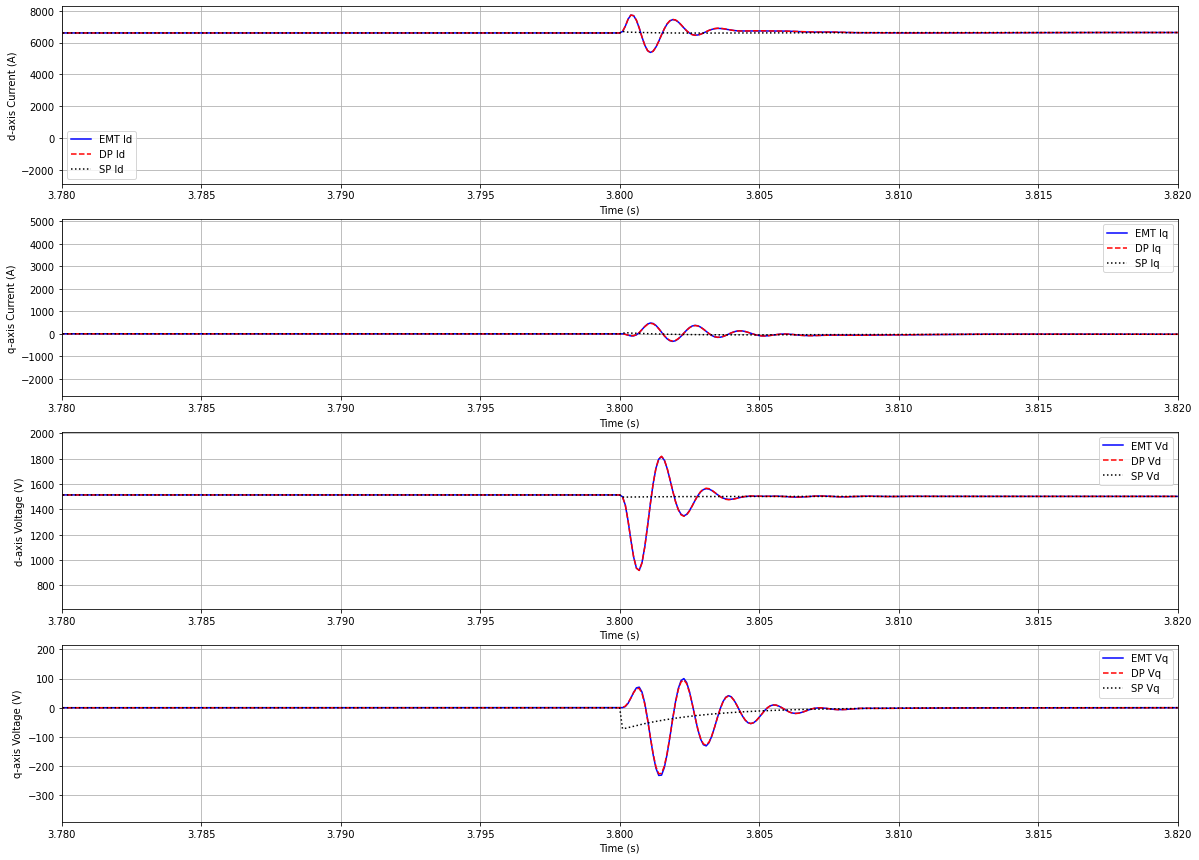

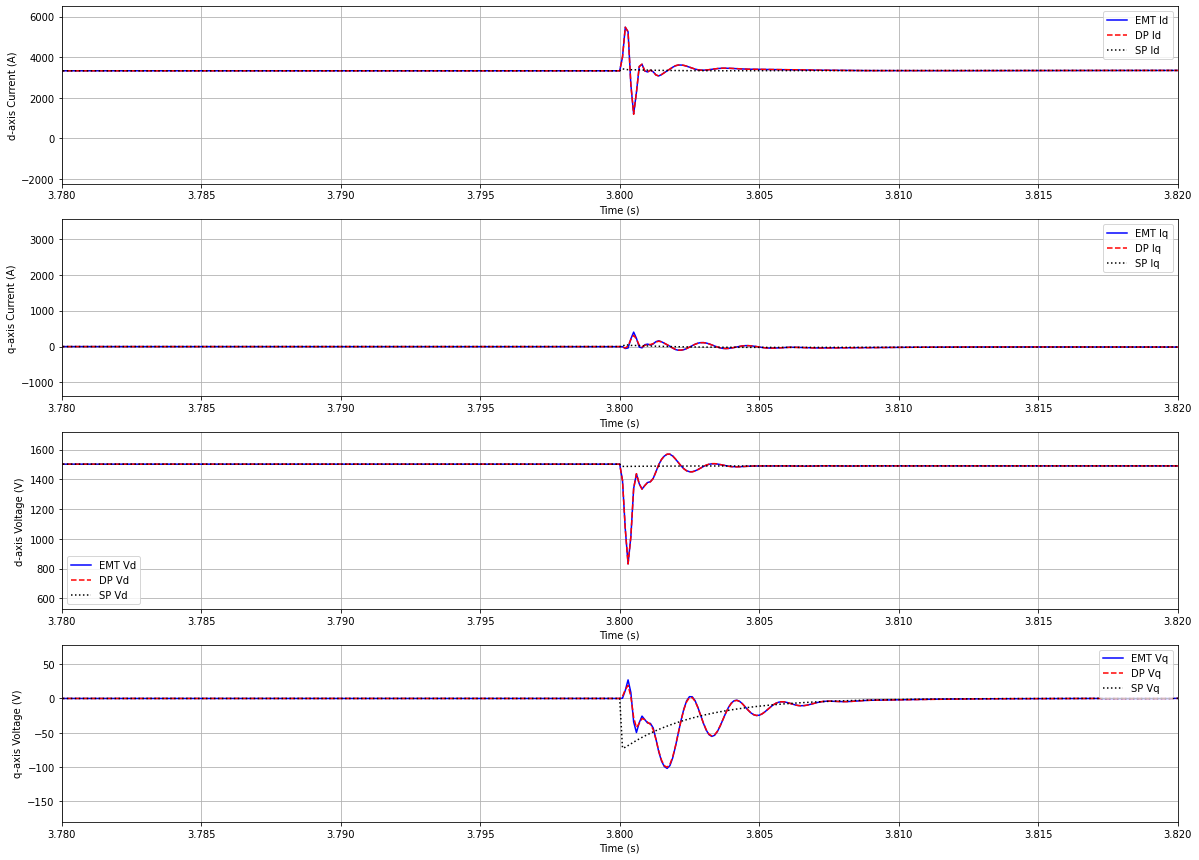

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Load data
def load_data(path_EMT, path_DP, path_SP):
    df_EMT = pd.read_csv(path_EMT)
    df_DP  = pd.read_csv(path_DP)
    df_SP  = pd.read_csv(path_SP)

    # Strip spaces from column names
    df_EMT.columns = df_EMT.columns.str.strip()
    df_DP.columns  = df_DP.columns.str.strip()
    df_SP.columns  = df_SP.columns.str.strip()

    print("DP columns:", df_DP.columns)

    return df_EMT, df_DP, df_SP

# 2) Compute base parameters
def compute_base_values():
    baseVoltageLineToLine   = 110e3
    baseVoltageLineToGround = baseVoltageLineToLine / np.sqrt(3)
    basePowerThreePhase     = 100e6
    baseCurrent             = basePowerThreePhase / baseVoltageLineToLine / np.sqrt(3)
    return baseCurrent, baseVoltageLineToLine

# ----- PLOT FUNCTIONS -----
def plot_load(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage):
    plt.figure(1, figsize=(20, 15))
    # Subplot 1: Load currents
    plt.subplot(2, 1, 1)
    plt.grid(True)
    EMT_load_I0 = (df_EMT['iLoad1_0'] + df_EMT['iLoad2_0']) / baseCurrent / np.sqrt(2)
    EMT_load_I1 = (df_EMT['iLoad1_1'] + df_EMT['iLoad2_1']) / baseCurrent / np.sqrt(2)
    EMT_load_I2 = (df_EMT['iLoad1_2'] + df_EMT['iLoad2_2']) / baseCurrent / np.sqrt(2)
    plt.plot(df_EMT['time'], EMT_load_I0, label='EMT Iload_0')
    plt.plot(df_EMT['time'], EMT_load_I1, label='EMT Iload_1')
    plt.plot(df_EMT['time'], EMT_load_I2, label='EMT Iload_2')

    Iload_DP = np.abs(df_DP['iLoad1.re'] + df_DP['iLoad2.re'] + 1j*df_DP['iLoad1.im'] + 1j*df_DP['iLoad2.im']) / baseCurrent / np.sqrt(3)
    Iload_SP = np.abs(df_SP['iLoad1.re'] + df_SP['iLoad2.re'] + 1j*df_SP['iLoad1.im'] + 1j*df_SP['iLoad2.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], Iload_DP, 'r--', label='DP Iload')
    plt.plot(df_SP['time'], Iload_SP, 'k--', label='SP Iload')
    plt.xlabel('Time (s)')
    plt.ylabel('Load Current (p.u.)')
    plt.xlim(3.78, 3.82)
    plt.legend()

    # Subplot 2: Load voltages
    plt.subplot(2, 1, 2)
    plt.grid(True)
    v0 = df_EMT['vLoad_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    v1 = df_EMT['vLoad_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    v2 = df_EMT['vLoad_2'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    plt.plot(df_EMT['time'], v0, label='EMT Vload_0')
    plt.plot(df_EMT['time'], v1, label='EMT Vload_1')
    plt.plot(df_EMT['time'], v2, label='EMT Vload_2')

    Vload_DP = np.abs(df_DP['vLoad.re'] + 1j*df_DP['vLoad.im']) / baseVoltage
    Vload_SP = np.abs(df_SP['vLoad.re'] + 1j*df_SP['vLoad.im']) / baseVoltage
    plt.plot(df_DP['time'], Vload_DP, 'r--', label='DP Vload')
    plt.plot(df_SP['time'], Vload_SP, 'k--', label='SP Vload')
    plt.xlabel('Time (s)')
    plt.ylabel('Load Voltage (p.u.)')
    plt.xlim(3.78, 3.82)
    plt.legend()


def plot_infeed(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage):
    plt.figure(2, figsize=(20, 15))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], -df_EMT['iInfeed_0'] / baseCurrent / np.sqrt(2), label='EMT Iinf_0')
    plt.plot(df_EMT['time'], -df_EMT['iInfeed_1'] / baseCurrent / np.sqrt(2), label='EMT Iinf_1')
    plt.plot(df_EMT['time'], -df_EMT['iInfeed_2'] / baseCurrent / np.sqrt(2), label='EMT Iinf_2')

    Iinf_DP = np.abs(df_DP['iInfeed.re'] + 1j * df_DP['iInfeed.im']) / baseCurrent / np.sqrt(3)
    Iinf_SP = np.abs(df_SP['iInfeed.re'] + 1j * df_SP['iInfeed.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], Iinf_DP, 'r--', label='DP Iinf')
    plt.plot(df_SP['time'], Iinf_SP, 'k--', label='SP Iinf')
    plt.xlabel('Time (s)')
    plt.ylabel('Infeed Current (p.u.)')
    plt.xlim(3.78, 3.82)
    # plt.legend()

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vInfeed_0']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vinf_0')
    plt.plot(df_EMT['time'], df_EMT['vInfeed_1']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vinf_1')
    plt.plot(df_EMT['time'], df_EMT['vInfeed_2']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vinf_2')

    Vinf_DP = np.abs(df_DP['vInfeed.re'] + 1j * df_DP['vInfeed.im']) / baseVoltage
    Vinf_SP = np.abs(df_SP['vInfeed.re'] + 1j * df_SP['vInfeed.im']) / baseVoltage
    plt.plot(df_DP['time'], Vinf_DP, 'r--', label='DP Vinf')
    plt.plot(df_SP['time'], Vinf_SP, 'k--', label='SP Vinf')
    plt.xlabel('Time (s)')
    plt.ylabel('Infeed Voltage (p.u.)')
    plt.xlim(3.78, 3.82)
    # plt.legend()


def plot_converter1(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage):
    plt.figure(3, figsize=(20, 15))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    EMT_I1_0 = df_EMT['iLine1_0'] / baseCurrent / np.sqrt(2)
    EMT_I1_1 = df_EMT['iLine1_1'] / baseCurrent / np.sqrt(2)
    EMT_I1_2 = df_EMT['iLine1_2'] / baseCurrent / np.sqrt(2)
    plt.plot(df_EMT['time'], EMT_I1_0, label='EMT ILine1_0')
    plt.plot(df_EMT['time'], EMT_I1_1, label='EMT ILine1_1')
    plt.plot(df_EMT['time'], EMT_I1_2, label='EMT ILine1_2')

    I1_DP = np.abs(df_DP['iLine1.re'] + 1j * df_DP['iLine1.im']) / baseCurrent / np.sqrt(3)
    I1_SP = np.abs(df_SP['iLine1.re'] + 1j * df_SP['iLine1.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], I1_DP, 'r--', label='DP ILine1')
    plt.plot(df_SP['time'], I1_SP, 'k--', label='SP ILine1')
    plt.xlabel('Time (s)')
    plt.ylabel('Line1 Current (p.u.)')
    plt.xlim(3.78, 3.82)
    # plt.legend()

    plt.subplot(2, 1, 2)
    plt.grid(True)
    V1_0 = df_EMT['vConverter1_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    V1_1 = df_EMT['vConverter1_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    V1_2 = df_EMT['vConverter1_2'] / baseVoltage  * np.sqrt(3) / np.sqrt(2)
    plt.plot(df_EMT['time'], V1_0, label='EMT Vconv1_0')
    plt.plot(df_EMT['time'], V1_1, label='EMT Vconv1_1')
    plt.plot(df_EMT['time'], V1_2, label='EMT Vconv1_2')

    V1_DP = np.abs(df_DP['vConverter1.re'] + 1j * df_DP['vConverter1.im']) / baseVoltage
    V1_SP = np.abs(df_SP['vConverter1.re'] + 1j * df_SP['vConverter1.im']) / baseVoltage
    plt.plot(df_DP['time'], V1_DP, 'r--', label='DP Vconv1')
    plt.plot(df_SP['time'], V1_SP, 'k--', label='SP Vconv1')
    plt.xlabel('Time (s)')
    plt.ylabel('Converter1 Voltage (p.u.)')
    plt.xlim(3.78, 3.82)
    # plt.legend()

def plot_converter2(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage):
    plt.figure(4, figsize=(20, 15))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    EMT_I2_0 = df_EMT['iLine2_0'] / baseCurrent / np.sqrt(2)
    EMT_I2_1 = df_EMT['iLine2_1'] / baseCurrent / np.sqrt(2)
    EMT_I2_2 = df_EMT['iLine2_2'] / baseCurrent / np.sqrt(2)
    plt.plot(df_EMT['time'], EMT_I2_0, label='EMT Iconv2_0')
    plt.plot(df_EMT['time'], EMT_I2_1, label='EMT Iconv2_1')
    plt.plot(df_EMT['time'], EMT_I2_2, label='EMT Iconv2_2')

    I2_DP = np.abs(df_DP['iLine2.re'] + 1j * df_DP['iLine2.im']) / baseCurrent / np.sqrt(3)
    I2_SP = np.abs(df_SP['iLine2.re'] + 1j * df_SP['iLine2.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], I2_DP, 'r--', label='DP Iconv2')
    plt.plot(df_SP['time'], I2_SP, 'k--', label='SP Iconv2')
    plt.xlabel('Time (s)')
    plt.ylabel('Line2 Current (p.u.)')
    plt.xlim(3.78, 3.82)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.grid(True)
    V2_0 = df_EMT['vConverter2_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    V2_1 = df_EMT['vConverter2_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    V2_2 = df_EMT['vConverter2_2'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    plt.plot(df_EMT['time'], V2_0, label='EMT Vconv2_0')
    plt.plot(df_EMT['time'], V2_1, label='EMT Vconv2_1')
    plt.plot(df_EMT['time'], V2_2, label='EMT Vconv2_2')

    V2_DP = np.abs(df_DP['vConverter2.re'] + 1j * df_DP['vConverter2.im']) / baseVoltage
    V2_SP = np.abs(df_SP['vConverter2.re'] + 1j * df_SP['vConverter2.im']) / baseVoltage
    plt.plot(df_DP['time'], V2_DP, 'r--', label='DP Vconv2')
    plt.plot(df_SP['time'], V2_SP, 'k--', label='SP Vconv2')
    plt.xlabel('Time (s)')
    plt.ylabel('Converter2 Voltage (p.u.)')
    plt.xlim(3.78, 3.82)
    plt.legend()

def plot_converter1InternalVariables(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage):
    plt.figure(5, figsize=(20, 15))  # Adjust figure size for better layout

    # Define consistent colors for EMT, DP, and SP
    colors = {'EMT': 'blue', 'DP': 'red', 'SP': 'black'}

    # Plot d-axis currents
    plt.subplot(4, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['idConverter1'], label='EMT Id', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'], df_DP['idConverter1'], label='DP Id', linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'], df_SP['idConverter1'], label='SP Id', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('d-axis Current (A)')
    plt.xlim(3.78, 3.82)
    plt.legend()

    # Plot q-axis currents
    plt.subplot(4, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['iqConverter1'], label='EMT Iq', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'], df_DP['iqConverter1'], label='DP Iq', linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'], df_SP['iqConverter1'], label='SP Iq', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('q-axis Current (A)')
    plt.xlim(3.78, 3.82)
    plt.legend()

    # Plot d-axis voltages
    plt.subplot(4, 1, 3)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vdConverter1'], label='EMT Vd', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'], df_DP['vdConverter1'], label='DP Vd', linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'], df_SP['vdConverter1'], label='SP Vd', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('d-axis Voltage (V)')
    plt.xlim(3.78, 3.82)
    plt.legend()

    # Plot q-axis voltages
    plt.subplot(4, 1, 4)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vqConverter1'], label='EMT Vq', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'], df_DP['vqConverter1'], label='DP Vq', linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'], df_SP['vqConverter1'], label='SP Vq', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('q-axis Voltage (V)')
    plt.xlim(3.78, 3.82)
    plt.legend()

def plot_converter2InternalVariables(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage):
    plt.figure(6, figsize=(20, 15))  # Adjust figure size for better layout

    # Define consistent colors for EMT, DP, and SP
    colors = {'EMT': 'blue', 'DP': 'red', 'SP': 'black'}

    # Plot d-axis currents
    plt.subplot(4, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['idConverter2'], label='EMT Id', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'], df_DP['idConverter2'], label='DP Id', linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'], df_SP['idConverter2'], label='SP Id', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('d-axis Current (A)')
    plt.xlim(3.78, 3.82)
    plt.legend()

    # Plot q-axis currents
    plt.subplot(4, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['iqConverter2'], label='EMT Iq', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'], df_DP['iqConverter2'], label='DP Iq', linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'], df_SP['iqConverter2'], label='SP Iq', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('q-axis Current (A)')
    plt.xlim(3.78, 3.82)
    plt.legend()

    # Plot d-axis voltages
    plt.subplot(4, 1, 3)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vdConverter2'], label='EMT Vd', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'], df_DP['vdConverter2'], label='DP Vd', linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'], df_SP['vdConverter2'], label='SP Vd', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('d-axis Voltage (V)')
    plt.xlim(3.78, 3.82)
    plt.legend()

    # Plot q-axis voltages
    plt.subplot(4, 1, 4)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vqConverter2'], label='EMT Vq', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'], df_DP['vqConverter2'], label='DP Vq', linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'], df_SP['vqConverter2'], label='SP Vq', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('q-axis Voltage (V)')
    plt.xlim(3.78, 3.82)
    plt.legend()

def main():
    # Change paths here
    path_EMT = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/EMT_simulation/EMT_simulation.csv"
    path_DP  = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/DP_simulation/DP_simulation.csv"
    path_SP  = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/SP_simulation/SP_simulation.csv"

    df_EMT, df_DP, df_SP = load_data(path_EMT, path_DP, path_SP)
    baseCurrent, baseVoltage = compute_base_values()

    plot_load(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage)
    plot_infeed(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage)
    plot_converter1(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage)
    plot_converter2(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage)
    plot_converter1InternalVariables(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage)
    plot_converter2InternalVariables(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage)

    plt.show()

if __name__ == "__main__":
    main()
